# T013 · 从 PubChem 获取数据

**注意：** 本教程是 TeachOpenCADD 的一部分，该平台旨在教授领域特定技能并提供流程模板作为研究项目的起点。

作者：

- Jaime Rodríguez-Guerra, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Dominique Sydow, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)
- Yonghui Chen, 2019-2020, [Volkamer lab, Charité](https://volkamerlab.org/)


## 本教程目标

在本笔记本中，您将学习如何使用 API 网络服务在 [PubChem](https://pubchem.ncbi.nlm.nih.gov/) 中搜索与输入 SMILES 相似的化合物。


### *理论* 部分内容

- PubChem
- PubChem 的程序化访问


### *实践* 部分内容

* PubChem API 的简单示例
  * 如何获取化合物的 PubChem CID
  * 基于 PubChem CID 检索分子属性
  * 用 PubChem 描绘化合物
* 查询 PubChem 中相似化合物
  * 确定查询化合物
  * 创建任务并获取任务键
  * 任务完成后下载结果
  * 获取结果分子的规范 SMILES
  * 展示结果


## 参考文献

* 文献：
    * PubChem 2019 更新：[_Nucleic Acids Res._ (2019), __47__, D1102-1109](https://academic.oup.com/nar/article/47/D1/D1102/5146201)
    * PubChem 2021：[_Nucleic Acids Res._(2021), __49__, D1388–D1395](https://academic.oup.com/nar/article/49/D1/D1388/5957164)
* 文档：
    * [PubChem 来源信息](https://pubchem.ncbi.nlm.nih.gov/sources)
    * [PUG REST](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest)
    * [程序化访问](https://pubchemdocs.ncbi.nlm.nih.gov/programmatic-access)
    * [PubChem - 维基百科](https://en.wikipedia.org/wiki/PubChem)


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 13
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### PubChem

[PubChem](https://pubchem.ncbi.nlm.nih.gov/) 是一个开放的数据库，包含化学分子及其在生物测定中的测量活性，由[美国国家生物技术信息中心 (NCBI)](https://www.ncbi.nlm.nih.gov/) 维护，该中心隶属于[美国国立卫生研究院 (NIH)](https://www.nih.gov/)。它是世界上最大的免费化学信息数据库，收集自超过 770 个数据来源。有三个动态增长的主要子数据库，即物质、化合物和生物测定数据库。
截至 2020 年 8 月，PubChem 包含超过 1.1 亿个独特的化学结构和超过 2.7 亿个生物活性数据（[_Nucleic Acids Res._(2021), __49__, D1388–D1395](https://academic.oup.com/nar/article/49/D1/D1388/5957164)）。

这些化合物可以通过广泛的性质进行查询，包括化学结构、名称、碎片、化学式、分子量、XlogP、氢键供体和受体数量等。毫无疑问，PubChem 已经成为科学家、学生和公众的关键化学信息资源。

PubChem 的所有数据都可以通过网络界面和程序化接口免费访问。在这里，我们将学习如何使用 PubChem 的 API 做一些很酷的事情。


### PubChem 的程序化访问

出于某些原因，主要是历史原因，PubChem 提供了多种程序化访问开放数据的方式。

* [PUG-REST](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest) 是 PUG（Power User Gateway）网络服务的 Representational State Transfer (REST) 风格版本，兼具 HTTP 请求语法和可用功能。它还可以方便地访问其他 PUG 服务无法访问的 PubChem 记录信息。

* PUG-View 是另一个用于 PubChem 的 REST 风格网络服务。它可以提供 PubChem 记录的完整报告，包括第三方文本注释。

* PUG 通过一个公共网关接口 (CGI) 提供对 PubChem 服务的程序化访问。

* PUG-SOAP 使用简单对象访问协议 (SOAP) 访问 PubChem 数据。

* PubChemRDF REST 接口是用于 RDF 编码的 PubChem 数据的特殊接口。

关于 PubChem API 的更多详细信息，请查看 PubChem 文档中关于[程序化访问](https://pubchemdocs.ncbi.nlm.nih.gov/programmatic-access)的介绍。

在本教程中，我们将专注于 API 的 **PUG-REST** 变体，相关介绍请参考**教程 T011**。


## 实践

在本节中，我们将讨论如何使用 PUG-REST 访问方式，基于给定的查询分子搜索 PubChem。


In [2]:
import time
from pathlib import Path
from urllib.parse import quote

from IPython.display import Markdown, Image, HTML
import requests
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import MolsToGridImage

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

### PubChem API 的简单示例
在查询 PubChem 中相似化合物之前，我们提供一些简单示例来展示如何使用 PubChem API。关于 PubChem API 的更多细节，请参阅 [PUG-REST 教程](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest-tutorial)。

#### 如何获取化合物的 PubChem CID
例如，我们将按名称搜索 Aspirin 的 PubChem 化合物标识符 (CID)。


In [4]:
# 按名称获取 PubChem CID
name = "aspirin"

url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{name}/cids/JSON"

r = requests.get(url)
r.raise_for_status()
response = r.json()
if "IdentifierList" in response:
    cid = response["IdentifierList"]["CID"][0]
else:
    raise ValueError(f"Could not find matches for compound: {name}")
print(f"{name} 的 PubChem CID 是：\n{cid}")
# NBVAL_CHECK_OUTPUT

PubChem CID for aspirin is:
2244


#### 基于 PubChem CID 检索分子属性
我们可以通过化合物的 PubChem CID 获取其有趣的属性，例如分子量、pKd、logP 等。这里，我们将搜索 Aspirin 的分子量。


In [5]:
# 获取阿司匹林的分子量
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/MolecularWeight/JSON"

r = requests.get(url)
r.raise_for_status()
response = r.json()

if "PropertyTable" in response:
    mol_weight = response["PropertyTable"]["Properties"][0]["MolecularWeight"]
else:
    raise ValueError(f"Could not find matches for PubChem CID: {cid}")
print(f"{name} 的分子量是：\n{mol_weight}")
# NBVAL_CHECK_OUTPUT

Molecular weight for aspirin is:
180.16


#### 用 PubChem 描绘化合物


The 2D structure of Aspirin:

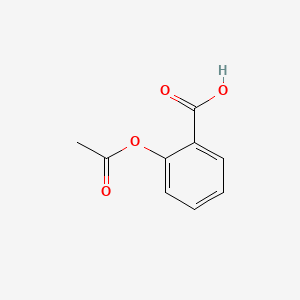

In [6]:
# 从 PubChem 获取 PNG 图像
url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/PNG"

r = requests.get(url)
r.raise_for_status()

display(Markdown("Aspirin 的 2D 结构："))
display(Image(r.content))

### 查询 PubChem 中的相似化合物
使用查询化合物的 `SMILES` 字符串在 PubChem 中搜索相似化合物。

> 提示：您可以查看**教程 T001** 了解如何使用 ChEMBL 数据库执行类似操作。

我们定义一个函数来查询 PubChem 服务中与给定化合物相似的化合物。这里将计算基于 Tanimoto 系数的 (2D) PubChem 指纹相似度。您可以查看[这篇论文](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-016-0163-1)了解更多关于 PubChem 中相似性评估的细节，以及 [PubChem 指纹规范](https://ftp.ncbi.nlm.nih.gov/pubchem/specifications/pubchem_fingerprints.pdf)了解更多关于 PubChem 指纹的细节。


#### 1. 确定查询化合物
在以下步骤中，我们将从 PubChem 服务中搜索与 Gefitinib（一种 EGFR 抑制剂）相似的化合物。您也可以选择其他感兴趣的化合物。


The structure of Gefitinib:


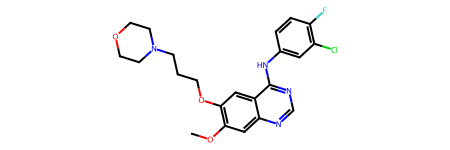

In [7]:
query = "COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4"  # Gefitinib
print("Gefitinib 的结构：")
Chem.MolFromSmiles(query)

#### 2. 创建任务并获取任务键

输入给定化合物的规范 `SMILES` 字符串以创建新任务，这样我们就能获得一个任务键。请注意，此异步 API 不会立即返回数据。在这种情况下，只有当请求的资源准备就绪时才会提供回调，这可以通过任务键来检查。因此，异步请求对于处理某些较慢的操作非常有用。


In [8]:
def query_pubchem_for_similar_compounds(smiles, threshold=75, n_records=10):
    """
    查询 PubChem 中相似化合物并返回任务键。

    Parameters
    ----------
    smiles : str
        给定化合物的规范 SMILES 字符串。
    threshold : int
        相似度阈值，默认为 75%。在 PubChem 中，默认阈值为 90%。
    n_records : int
        最大反馈记录数。

    Returns
    -------
    str
        来自 PubChem 网络服务的任务键。
    """
    escaped_smiles = quote(smiles).replace("/", ".")
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/similarity/smiles/{escaped_smiles}/JSON?Threshold={threshold}&MaxRecords={n_records}"
    r = requests.get(url)
    r.raise_for_status()
    key = r.json()["Waiting"]["ListKey"]
    return key

In [9]:
job_key = query_pubchem_for_similar_compounds(query)
job_key

'1817476401915959628'

#### 3. 任务完成后下载结果
检查任务是否在时间限制内完成。PubChem 的标准时间限制是 30 秒（我们可以重置它）。这意味着如果请求未在时间限制内完成，将返回超时错误。所以，只需耐心等待回调。

然后在任务完成时下载结果——在本例中是 PubChem CID。


In [10]:
def check_and_download(key, attempts=30):
    """
    检查任务状态并在任务完成时下载 PubChem CID

    Parameters
    ----------
    key : str
        PubChem 服务的任务键。
    attempts : int
        等待 PubChem 服务反馈的时间。

    Returns
    -------
    list
        相似化合物的 PubChem CID 列表。
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/listkey/{key}/cids/JSON"
    print(f"Querying for job {key} at URL {url}...", end="")
    while attempts:
        r = requests.get(url)
        r.raise_for_status()
        response = r.json()
        if "IdentifierList" in response:
            cids = response["IdentifierList"]["CID"]
            break
        attempts -= 1
        print(".", end="")
        time.sleep(10)
    else:
        raise ValueError(f"Could not find matches for job key: {key}")
    return cids

In [11]:
similar_cids = check_and_download(job_key)

Querying for job 1817476401915959628 at URL https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/listkey/1817476401915959628/cids/JSON....

#### 4. 获取结果分子的规范 SMILES


In [12]:
similar_cids

[2092, 176870, 208908, 3081361, 3157, 4893, 5401, 5583, 123631, 68546]

In [13]:
def smiles_from_pubchem_cids(cids):
    """
    从 PubChem CID 获取规范 SMILES 字符串。

    Parameters
    ----------
    cids : list
        PubChem CID 列表。

    Returns
    -------
    list
        PubChem CID 的规范 SMILES 字符串列表。
    """
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{','.join(map(str, cids))}/property/CanonicalSMILES/JSON"
    r = requests.get(url)
    r.raise_for_status()
    return [item.get("ConnectivitySMILES") for item in r.json()["PropertyTable"]["Properties"]]

In [14]:
similar_smiles = smiles_from_pubchem_cids(similar_cids)

In [15]:
similar_smiles

['CN(CCCNC(=O)C1CCCO1)C2=NC3=CC(=C(C=C3C(=N2)N)OC)OC',
 'COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C)OCCOC',
 'CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3NC4=CC(=C(C=C4)OCC5=CC(=CC=C5)F)Cl',
 'CN1CCC(CC1)COC2=C(C=C3C(=C2)N=CN=C3NC4=C(C=C(C=C4)Br)F)OC',
 'COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4COC5=CC=CC=C5O4)N)OC',
 'COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4=CC=CO4)N)OC',
 'COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4CCCO4)N)OC',
 'CC1=C(C=CC2=C1C(=NC(=N2)N)N)CNC3=CC(=C(C(=C3)OC)OC)OC',
 'COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OCCCN4CCOCC4',
 'COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4=CC=CO4)N)OC.Cl']

然后，我们创建 RDKit 分子并描绘它们。


In [16]:
query_results_df = pd.DataFrame({"smiles": similar_smiles, "CIDs": similar_cids})
# 2. 修复：过滤 DataFrame 以删除 'smiles' 值为 None 的行。
# 这可以防止 RDKit 尝试处理无效输入。
query_results_df.dropna(subset=["smiles"], inplace=True)
PandasTools.AddMoleculeColumnToFrame(query_results_df, smilesCol="smiles")
query_results_df.head(5)

,smiles,CIDs,ROMol
0,CN(CCCNC(=O)C1CCCO1)C2=NC3=CC(=C(C=C3C(=N2)N)O...,2092,<rdkit.Chem.rdchem.Mol object at 0x7f1d89874dd0>
1,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,176870,<rdkit.Chem.rdchem.Mol object at 0x7f1d89874ba0>
2,CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3...,208908,<rdkit.Chem.rdchem.Mol object at 0x7f1d89875000>
3,CN1CCC(CC1)COC2=C(C=C3C(=C2)N=CN=C3NC4=C(C=C(C...,3081361,<rdkit.Chem.rdchem.Mol object at 0x7f1d89874f90>
4,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4CO...,3157,<rdkit.Chem.rdchem.Mol object at 0x7f1d89874b30>


,smiles,CIDs,ROMol
0,CN(CCCNC(=O)C1CCCO1)C2=NC3=CC(=C(C=C3C(=N2)N)O...,2092,
1,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,176870,
2,CS(=O)(=O)CCNCC1=CC=C(O1)C2=CC3=C(C=C2)N=CN=C3...,208908,
3,CN1CCC(CC1)COC2=C(C=C3C(=C2)N=CN=C3NC4=C(C=C(C...,3081361,
4,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4CO...,3157,
5,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4=C...,4893,
6,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4CC...,5401,
7,CC1=C(C=CC2=C1C(=NC(=N2)N)N)CNC3=CC(=C(C(=C3)O...,5583,
8,COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...,123631,
9,COC1=C(C=C2C(=C1)C(=NC(=N2)N3CCN(CC3)C(=O)C4=C...,68546,

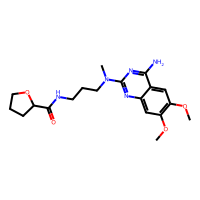
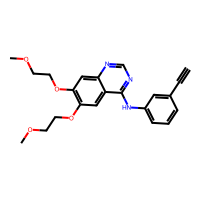
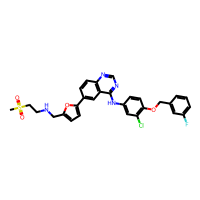
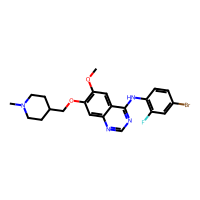
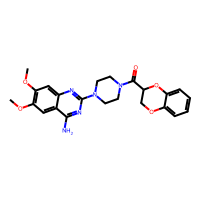
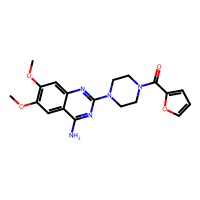
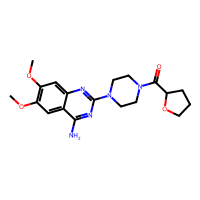
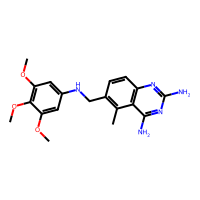
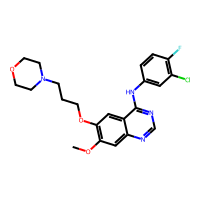
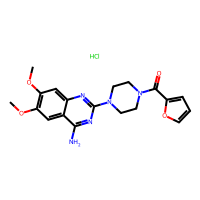

In [17]:
query_results_df

#### 5. 展示结果
使用 RDKit 的绘图功能以图像形式展示化合物。


In [18]:
def multi_preview_smiles(query_smiles, query_name, similar_molecules_pd):
    """
    以 2D 结构表示形式展示查询和相似化合物。

    Parameters
    ----------
    query_smiles : str
        查询化合物的 SMILES 字符串。
    query_name : str
        查询化合物的名称。
    similar_molecules_pd : pandas
        包含相似分子 SMILES 字符串和 CID 的 pandas DataFrame。

    Returns
    -------
    MolsToGridImage
    """

    # 处理输入 DataFrame 为空的情况（例如，所有 CID 都失败）。
    if similar_molecules_pd.empty:
        return HTML(
            f"<p style='color:red;'>No similar compounds were successfully retrieved. Cannot generate image.</p>"
        )

    # 仅在 DataFrame 不为空时继续
    legends = [f"PubChem CID: {str(s)}" for s in similar_molecules_pd["CIDs"].tolist()]

    # 过滤掉任何 None 值
    molecules = [Chem.MolFromSmiles(s) for s in similar_molecules_pd["smiles"]]
    molecules = [mol for mol in molecules if mol is not None]

    # 检查查询分子是否可以绘制
    if not molecules and len(similar_molecules_pd) > 0:
        print("Note: The list of similar compounds resulted in no valid RDKit molecules.")

    query_mol = Chem.MolFromSmiles(query_smiles)

    # 包含查询分子。
    # 要绘制的总分子数为 len(molecules) + 1（查询分子）。
    total_mols = len(molecules) + 1

    return MolsToGridImage(
        [query_mol] + molecules,
        molsPerRow=3,
        subImgSize=(300, 300),
        maxMols=total_mols,  # Corrected from len(molecules)
        legends=([query_name] + legends),
        useSVG=True,
    )

The results of querying similar compounds for Gefitinib:


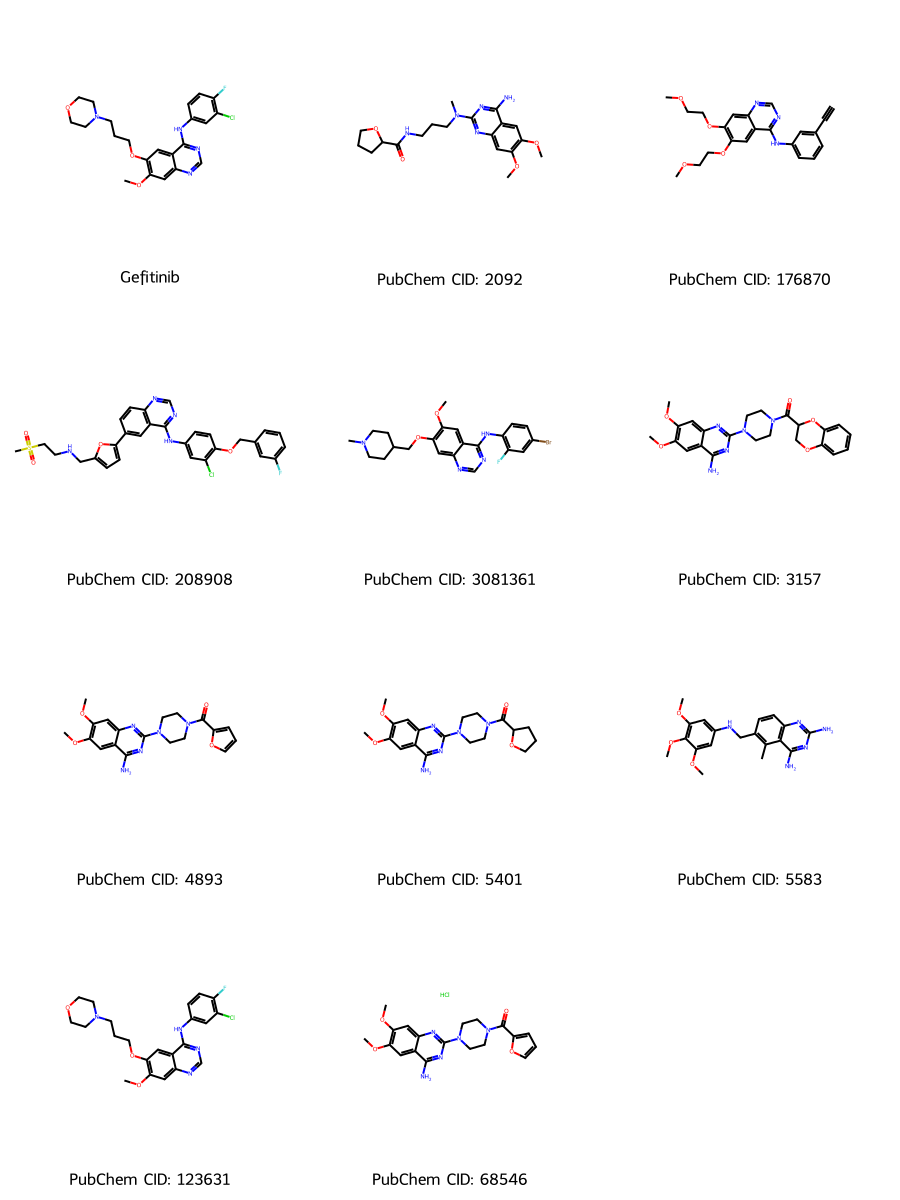

In [19]:
print("查询 Gefitinib 相似化合物的结果：")
img = multi_preview_smiles(query, "Gefitinib", query_results_df)
img

## Discussion

In this notebook, you have learned how to access and search similar compounds from the PubChem database via the PUG-REST programmatic access. Is it convenient? PUG-REST can do more than that. See [PUG-REST](https://pubchemdocs.ncbi.nlm.nih.gov/pug-rest-tutorial) to get more power! 


## Quiz

- Can you make the similarity search more strict?
- Is any of the proposed candidates already an approved inhibitor? (Hint: You can _scrape_ [PKIDB](https://www.icoa.fr/pkidb/index.html) and check against the list of SMILES, also see **Talktorial T011**)
- Can you try to reuse the functions in this notebook so search for similar compounds to Imatinib and inspect your results?